# Arcos e Ângulos

**Módulo:** 05 – Trigonometria (1º notebook do módulo)

**Pré-requisitos:** [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (operações básicas em Python, variáveis, funções simples, biblioteca `math`) e [`04_geometria_plana/`](../04_geometria_plana/) (definição de circunferência, raio, perímetro, proporcionalidade)

**Objetivos de aprendizagem:**
- Converter medidas de arcos e ângulos entre graus e radianos com fluência.
- Calcular o comprimento de um arco de circunferência a partir do raio e do ângulo central.
- Localizar um arco no ciclo trigonométrico e identificar em que quadrante ele está.
- Reconhecer arcos côngruos (coterminais) e escrever a expressão geral de arcos côngruos a um arco dado.

**Tempo estimado:** 70 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0501a_arcos_e_angulos.ipynb)

## Uma volta na roda-gigante

Uma roda-gigante tem 15 metros de raio e leva 4 minutos para completar uma volta. Depois de girar 50°, quantos metros uma cadeira já percorreu ao longo do arco? E se a roda-gigante tivesse o dobro do raio, a cadeira percorreria o dobro da distância para o mesmo ângulo?

Ainda não temos as ferramentas para responder isso de forma direta — mas ao final deste notebook, o problema vai cair em poucas linhas de código. (E depois de resolvido, vale voltar aqui e pensar: sua intuição sobre "dobrar o raio" bateu com a conta?)

In [1]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Arcos de Circunferência

Pegue uma circunferência qualquer e marque dois pontos sobre ela, A e B. Esses dois pontos dividem a circunferência em duas partes — cada uma delas é um **arco** de extremos A e B.

Não confunda arco com **corda**: a corda é o segmento de reta que liga A a B "por dentro" do círculo; o arco é o caminho "pela borda", seguindo a curva da circunferência. Na figura abaixo, a linha tracejada é a corda AB, e o trecho grosso é o arco AB — visivelmente mais longo, porque acompanha a curva em vez de cortar caminho.

Por enquanto, pense no comprimento de um arco de forma intuitiva: é a distância que você percorreria andando sobre a circunferência, de A até B, sem atalhos. Uma fórmula exata vem no Bloco 4 — antes disso, precisamos de uma unidade adequada para medir o ângulo que "abre" o arco.

📌 **Definição formal:** dados dois pontos A e B sobre uma circunferência, cada uma das duas partes em que eles a dividem é chamada de **arco** de extremos A e B.

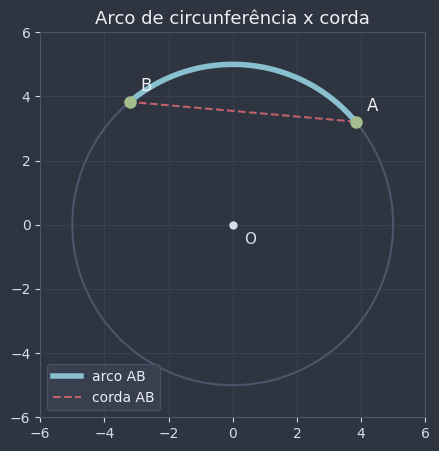

In [2]:
raio_exemplo = 5
angulo_inicial = 40
angulo_final = 130

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

# circunferência completa (linha fina)
angulos_completos = np.linspace(0, 360, 200)
x_completo = raio_exemplo * np.cos(np.radians(angulos_completos))
y_completo = raio_exemplo * np.sin(np.radians(angulos_completos))
ax.plot(x_completo, y_completo, color=NORD_LINHA, linewidth=1.5)

# arco destacado
angulos_arco = np.linspace(angulo_inicial, angulo_final, 100)
x_arco = raio_exemplo * np.cos(np.radians(angulos_arco))
y_arco = raio_exemplo * np.sin(np.radians(angulos_arco))
ax.plot(x_arco, y_arco, color=COR_PONTO, linewidth=4, label="arco AB")

# corda, para contraste com o arco
ax.plot(
    [x_arco[0], x_arco[-1]], [y_arco[0], y_arco[-1]],
    "--", color=COR_ALERTA, linewidth=1.5, label="corda AB",
)

# extremos e centro
ax.plot(0, 0, "o", color=NORD_TEXTO_SEC, markersize=5)
ax.plot(x_arco[0], y_arco[0], "o", color=COR_DESTAQUE, markersize=8)
ax.plot(x_arco[-1], y_arco[-1], "o", color=COR_DESTAQUE, markersize=8)
ax.annotate("A", (x_arco[0], y_arco[0]), color=NORD_TEXTO, fontsize=12, xytext=(8, 8), textcoords="offset points")
ax.annotate("B", (x_arco[-1], y_arco[-1]), color=NORD_TEXTO, fontsize=12, xytext=(8, 8), textcoords="offset points")
ax.annotate("O", (0, 0), color=NORD_TEXTO_SEC, fontsize=11, xytext=(8, -14), textcoords="offset points")

ax.set_xlim(-raio_exemplo - 1, raio_exemplo + 1)
ax.set_ylim(-raio_exemplo - 1, raio_exemplo + 1)
ax.set_aspect("equal")
ax.set_title("Arco de circunferência x corda", color=NORD_TEXTO, fontsize=13)
ax.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, loc="lower left")
plt.show()

**Pergunta de checagem:** um arco de circunferência pode ser maior que a própria circunferência? Por quê?

📖 **Leitura complementar:** [Arco (matemática)](https://pt.wikipedia.org/wiki/Arco_(matem%C3%A1tica))

## 2. Medidas de Arcos: o Grau

A forma mais familiar de medir um arco (ou o ângulo que ele determina) é em **graus**. Por definição, 1 grau (1°) é 1/360 de uma volta completa na circunferência — ou seja, a circunferência inteira mede 360°.

Essa escolha (360, e não 100 ou 1000) vem de milênios atrás, da matemática babilônica, que usava um sistema numérico de base 60. O número 360 tem a vantagem prática de ser divisível por muitos números inteiros (2, 3, 4, 5, 6, 8, 9, 10, 12...), o que facilita dividir um círculo em partes iguais sem usar frações complicadas.

Em provas e no dia a dia você também pode encontrar **minutos** e **segundos** como subdivisões do grau (1° = 60 minutos, 1 minuto = 60 segundos) — não é o foco deste curso, mas vale saber que essa notação existe.

💡 **Dica:** o grau é útil no dia a dia (é o que aparece no GPS, em rampas, em receitas de bolo giradas no forno...), mas a partir daqui o **radiano** vai virar a unidade "oficial" da matemática — é nele que praticamente todas as fórmulas de trigonometria e cálculo são escritas.

In [3]:
angulos_graus_comuns = [0, 30, 45, 60, 90, 180, 270, 360]

tabela_graus = pd.DataFrame({
    "angulo (graus)": angulos_graus_comuns,
    "fracao da circunferencia": [str(Fraction(angulo, 360)) for angulo in angulos_graus_comuns],
})
tabela_graus

,angulo (graus),fracao da circunferencia
0,0,0
1,30,1/12
2,45,1/8
3,60,1/6
4,90,1/4
5,180,1/2
6,270,3/4
7,360,1


**Pergunta de checagem:** quantos graus corresponde a 1/8 da circunferência?

## 3. Conversão entre Grau e Radiano

O radiano nasce de uma ideia bem natural: em vez de dividir a circunferência em 360 partes arbitrárias, por que não medir o ângulo pelo próprio comprimento do arco que ele determina?

📌 **Definição formal:** um ângulo mede **1 radiano** quando o arco que ele determina tem comprimento igual ao raio da circunferência.

Como a circunferência inteira tem comprimento 2πr (o perímetro), e cada "fatia" de 1 radiano consome um arco de comprimento igual a r, cabem exatamente 2π radianos numa volta completa. Isso dá a relação fundamental:

2π rad = 360°  ⟹  π rad = 180°

Dessa igualdade saem as duas fórmulas de conversão:

θ_rad = θ_graus · (π / 180)          θ_graus = θ_rad · (180 / π)

⚠️ **Erro comum:** o radiano não carrega uma "unidade" explícita — ele é, tecnicamente, uma razão entre dois comprimentos (arco / raio), então é um número puro. Por isso é comum ver um ângulo escrito só como `π/3`, sem símbolo nenhum depois, e o aluno achar que sumiu um passo da conta. Não sumiu nada: `π/3` **já é** o ângulo em radianos.

In [4]:
angulos_graus_notaveis = [0, 30, 45, 60, 90, 180, 270, 360]


def graus_para_radianos(angulo_graus: float) -> float:
    """Converte um ângulo de graus para radianos."""
    return angulo_graus * math.pi / 180


def radianos_para_graus(angulo_radianos: float) -> float:
    """Converte um ângulo de radianos para graus."""
    return angulo_radianos * 180 / math.pi


def fracao_de_pi(angulo_graus: float) -> str:
    """Escreve um ângulo em graus como fração de pi, em texto."""
    fracao = Fraction(angulo_graus, 180)
    if fracao == 0:
        return "0"
    return f"{fracao} pi"


tabela_conversao = pd.DataFrame({
    "angulo (graus)": angulos_graus_notaveis,
    "fracao de pi": [fracao_de_pi(angulo) for angulo in angulos_graus_notaveis],
    "radianos (decimal)": [round(graus_para_radianos(angulo), 4) for angulo in angulos_graus_notaveis],
})
tabela_conversao

,angulo (graus),fracao de pi,radianos (decimal)
0,0,0,0.0000
1,30,1/6 pi,0.5236
2,45,1/4 pi,0.7854
3,60,1/3 pi,1.0472
4,90,1/2 pi,1.5708
5,180,1 pi,3.1416
6,270,3/2 pi,4.7124
7,360,2 pi,6.2832


🕹️ **Widget interativo:** mova o slider em graus e veja, em tempo real, o valor correspondente em radianos — como fração de π e como decimal, junto com o ponto marcado na circunferência.

In [ ]:
def mostrar_conversao_grau_radiano(angulo_graus: int) -> None:
    radianos = graus_para_radianos(angulo_graus)
    texto_fracao = fracao_de_pi(angulo_graus)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 360, 200)
    ax.plot(
        raio_exemplo * np.cos(np.radians(angulos_completos)),
        raio_exemplo * np.sin(np.radians(angulos_completos)),
        color=NORD_LINHA, linewidth=1.5,
    )

    x_ponto = raio_exemplo * math.cos(radianos)
    y_ponto = raio_exemplo * math.sin(radianos)
    ax.plot([0, x_ponto], [0, y_ponto], color=COR_PONTO, linewidth=2)
    ax.plot(x_ponto, y_ponto, "o", color=COR_DESTAQUE, markersize=10)

    ax.set_xlim(-raio_exemplo - 1, raio_exemplo + 1)
    ax.set_ylim(-raio_exemplo - 1, raio_exemplo + 1)
    ax.set_aspect("equal")
    ax.set_title(
        f"{angulo_graus}° = {texto_fracao} rad = {radianos:.4f} rad",
        color=NORD_TEXTO, fontsize=12,
    )
    plt.show()


widgets.interact(
    mostrar_conversao_grau_radiano,
    angulo_graus=widgets.IntSlider(min=0, max=360, step=1, value=45, description="ângulo (°)"),
)

interactive(children=(IntSlider(value=45, description='ângulo (°)', max=360), Output()), _dom_classes=('widget…

<function __main__.mostrar_conversao_grau_radiano(angulo_graus: int) -> None>

**Pergunta de checagem:** por que 1 radiano vale aproximadamente 57,3°, e não um número redondo?

📖 **Leitura complementar:** [Radiano](https://pt.wikipedia.org/wiki/Radiano)

## 4. Comprimento de Arco (s = r·θ)

A própria definição de radiano do bloco anterior já contém a fórmula que queremos: um ângulo de 1 radiano corresponde a um arco de comprimento igual ao raio; um ângulo de 2 radianos, ao dobro do raio. De forma geral, para um ângulo θ **em radianos**:

s = r · θ

onde s é o comprimento do arco e r é o raio da circunferência.

⚠️ Essa fórmula só funciona diretamente se θ estiver em radianos — é justamente por isso que o radiano é a unidade "natural" para essa conta: ele já embute a relação entre ângulo e comprimento, sem precisar de nenhuma constante extra de conversão.

🎯 **Aplicação prática:** hora de resolver o problema da roda-gigante do início do notebook. Raio de 15 metros, ângulo de 50°.

In [6]:
def comprimento_arco(raio: float, angulo_rad: float) -> float:
    """Calcula o comprimento de um arco, dado o raio e o ângulo central em radianos."""
    return raio * angulo_rad


# resolvendo o problema da roda-gigante
raio_roda_gigante = 15
angulo_roda_gigante_graus = 50
angulo_roda_gigante_rad = graus_para_radianos(angulo_roda_gigante_graus)
distancia_percorrida = comprimento_arco(raio_roda_gigante, angulo_roda_gigante_rad)

print(f"ângulo: {angulo_roda_gigante_graus}° = {angulo_roda_gigante_rad:.4f} rad")
print(f"comprimento do arco percorrido: {distancia_percorrida:.2f} metros")

distancia_dobro_raio = comprimento_arco(2 * raio_roda_gigante, angulo_roda_gigante_rad)
print(f"\ncom o dobro do raio, para o mesmo ângulo: {distancia_dobro_raio:.2f} metros")
print(f"(o dobro de {distancia_percorrida:.2f} é {2 * distancia_percorrida:.2f} -> a distância também dobrou)")

ângulo: 50° = 0.8727 rad
comprimento do arco percorrido: 13.09 metros

com o dobro do raio, para o mesmo ângulo: 26.18 metros
(o dobro de 13.09 é 26.18 -> a distância também dobrou)


📎 **Conexão:** faça θ = 2π na fórmula s = r·θ e você recupera o perímetro da circunferência (2πr) visto em `04_geometria_plana` — o perímetro é só o caso particular de "arco de uma volta completa".

🕹️ **Widget interativo:** mexa nos sliders de raio e ângulo e veja o arco e o comprimento s mudarem ao vivo.

In [7]:
def desenhar_arco_interativo(raio: float, angulo_graus: float) -> None:
    angulo_rad = graus_para_radianos(angulo_graus)
    comprimento = comprimento_arco(raio, angulo_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 360, 200)
    ax.plot(
        raio * np.cos(np.radians(angulos_completos)),
        raio * np.sin(np.radians(angulos_completos)),
        color=NORD_LINHA, linewidth=1.5,
    )

    angulos_arco = np.linspace(0, angulo_graus, 100)
    ax.plot(
        raio * np.cos(np.radians(angulos_arco)),
        raio * np.sin(np.radians(angulos_arco)),
        color=COR_PONTO, linewidth=4,
    )

    limite = raio + 1
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.set_aspect("equal")
    ax.set_title(
        f"raio = {raio:.0f}, ângulo = {angulo_graus:.0f}°  ->  s = {comprimento:.2f}",
        color=NORD_TEXTO, fontsize=12,
    )
    plt.show()


widgets.interact(
    desenhar_arco_interativo,
    raio=widgets.FloatSlider(min=1, max=20, step=1, value=15, description="raio"),
    angulo_graus=widgets.FloatSlider(min=0, max=360, step=5, value=50, description="ângulo (°)"),
)

interactive(children=(FloatSlider(value=15.0, description='raio', max=20.0, min=1.0, step=1.0), FloatSlider(va…

<function __main__.desenhar_arco_interativo(raio: float, angulo_graus: float) -> None>

**Pergunta de checagem:** se o ângulo dobrar e o raio for reduzido à metade, o que acontece com o comprimento do arco?

## 5. Ângulos entre Semirretas

Até aqui, tratamos arco e ângulo quase como sinônimos — e não por acaso: um **ângulo** é a região formada por duas semirretas que partem de uma mesma origem (o **vértice**), e a forma mais direta de medir essa "abertura" é observar o arco que ela recorta numa circunferência centrada no vértice.

📌 **Definição formal:** um ângulo é a reunião de duas semirretas de mesma origem. Sua medida (em radianos) é o comprimento do arco correspondente dividido pelo raio da circunferência usada para medi-lo — a mesma relação θ = s/r do Bloco 3, lida "ao contrário".

Repare que essa razão s/r não depende do tamanho da circunferência escolhida: um círculo pequeno recorta um arco pequeno, um círculo grande recorta um arco grande, mas a **proporção** entre arco e raio é sempre a mesma para o mesmo ângulo — é o que garante que a medida do ângulo é uma propriedade das duas semirretas, não do círculo usado para desenhá-lo.

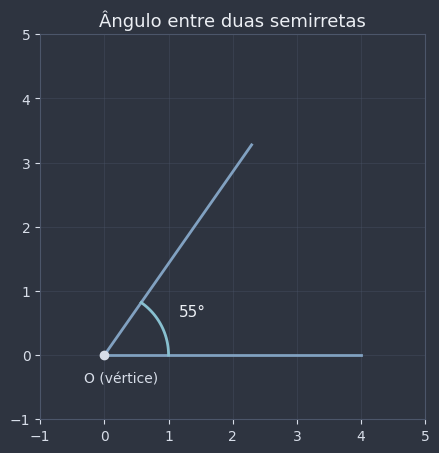

In [8]:
angulo_semirretas = 55
comprimento_semirreta = 4

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot([0, comprimento_semirreta], [0, 0], color=COR_SECUNDARIA, linewidth=2)
x_fim = comprimento_semirreta * math.cos(math.radians(angulo_semirretas))
y_fim = comprimento_semirreta * math.sin(math.radians(angulo_semirretas))
ax.plot([0, x_fim], [0, y_fim], color=COR_SECUNDARIA, linewidth=2)

raio_arco_angulo = 1
angulos_arco_angulo = np.linspace(0, angulo_semirretas, 50)
ax.plot(
    raio_arco_angulo * np.cos(np.radians(angulos_arco_angulo)),
    raio_arco_angulo * np.sin(np.radians(angulos_arco_angulo)),
    color=COR_PONTO, linewidth=2,
)

ax.plot(0, 0, "o", color=NORD_TEXTO_SEC, markersize=6)
ax.annotate("O (vértice)", (0, 0), color=NORD_TEXTO_SEC, fontsize=10, xytext=(-15, -20), textcoords="offset points")
angulo_meio_rad = math.radians(angulo_semirretas / 2)
ax.annotate(
    f"{angulo_semirretas}°",
    (1.3 * raio_arco_angulo * math.cos(angulo_meio_rad), 1.3 * raio_arco_angulo * math.sin(angulo_meio_rad)),
    color=NORD_TEXTO, fontsize=11,
)

ax.set_xlim(-1, comprimento_semirreta + 1)
ax.set_ylim(-1, comprimento_semirreta + 1)
ax.set_aspect("equal")
ax.set_title("Ângulo entre duas semirretas", color=NORD_TEXTO, fontsize=13)
plt.show()

**Pergunta de checagem:** dois ângulos podem ter a mesma abertura mesmo com raios diferentes desenhados na figura? Isso muda a medida do ângulo?

## 6. Medida e Classificação de Ângulos

Ângulos são medidos exatamente nas mesmas unidades que arcos — grau ou radiano — porque, como vimos, são a mesma ideia vista de dois ângulos (literalmente). Uma classificação rápida, útil para revisão:

| Classificação | Faixa (graus) |
|---|---|
| Agudo | 0° < θ < 90° |
| Reto | θ = 90° |
| Obtuso | 90° < θ < 180° |
| Raso | θ = 180° |
| De uma volta | θ = 360° |

💡 **Dica:** "ângulo raso" (180°) e "arco de meia volta" são a mesma coisa vista de duas formas — assim como "ângulo de uma volta" (360°) e a circunferência completa.

In [9]:
def classificar_angulo(angulo_graus: float) -> str:
    """Classifica um ângulo entre 0° (exclusivo) e 360° (inclusivo)."""
    if angulo_graus <= 0 or angulo_graus > 360:
        return "fora do intervalo (0°, 360°]"
    if angulo_graus < 90:
        return "agudo"
    if angulo_graus == 90:
        return "reto"
    if angulo_graus < 180:
        return "obtuso"
    if angulo_graus == 180:
        return "raso"
    if angulo_graus < 360:
        return "não convexo (reflexo)"
    return "de uma volta"


for angulo_teste in [30, 90, 95, 180, 270, 360]:
    print(f"{angulo_teste}°: {classificar_angulo(angulo_teste)}")

30°: agudo
90°: reto
95°: obtuso
180°: raso
270°: não convexo (reflexo)
360°: de uma volta


**Pergunta de checagem:** um ângulo de 95° é agudo, reto ou obtuso?

## 7. O Ciclo Trigonométrico

Para estudar arcos e ângulos de forma sistemática, a matemática usa uma circunferência "padrão": o **ciclo trigonométrico** (ou círculo unitário) — uma circunferência de **raio 1**, centrada na origem do plano cartesiano.

📌 **Definição formal:** o ciclo trigonométrico é a circunferência de equação x² + y² = 1. A origem dos arcos é o ponto A = (1, 0); o sentido **positivo** de percurso é o anti-horário, e o sentido **negativo** é o horário.

Cada ponto do ciclo trigonométrico tem coordenadas (x, y) que dependem só do ângulo percorrido a partir de A — ainda não vamos dar nome a essas coordenadas (isso é assunto do próximo notebook do módulo), mas já dá para localizar qualquer arco como um ponto (x, y) sobre essa circunferência.

🕵️ **Curiosidade histórica:** a convenção do sentido anti-horário como "positivo" não tem nenhuma razão matemática profunda — é uma convenção. Uma hipótese comum é que ela vem da forma como astrônomos gregos e árabes desenhavam o céu, olhando "de dentro" da esfera celeste para fora, o que inverte o sentido aparente comparado a olhar um relógio de fora.

In [10]:
angulos_notaveis_ciclo = [0, 30, 45, 60, 90, 180, 270]

tabela_ciclo = pd.DataFrame({
    "angulo (graus)": angulos_notaveis_ciclo,
    "x": [round(math.cos(graus_para_radianos(a)), 4) for a in angulos_notaveis_ciclo],
    "y": [round(math.sin(graus_para_radianos(a)), 4) for a in angulos_notaveis_ciclo],
})
tabela_ciclo

,angulo (graus),x,y
0,0,1.0000,0.0000
1,30,0.8660,0.5000
2,45,0.7071,0.7071
3,60,0.5000,0.8660
4,90,0.0000,1.0000
5,180,-1.0000,0.0000
6,270,-0.0000,-1.0000


🕹️ **Widget interativo:** mova o slider de ângulo (0 a 2π) e observe o ponto se deslocando ao longo do ciclo trigonométrico.

In [11]:
def mover_ponto_ciclo(angulo_rad: float) -> None:
    x = math.cos(angulo_rad)
    y = math.sin(angulo_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    ax.plot(1, 0, "o", color=NORD_TEXTO_SEC, markersize=6)
    ax.annotate("origem dos arcos", (1, 0), color=NORD_TEXTO_SEC, fontsize=9, xytext=(6, 6), textcoords="offset points")

    ax.plot([0, x], [0, y], color=COR_PONTO, linewidth=1.5)
    ax.plot(x, y, "o", color=COR_DESTAQUE, markersize=10)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(f"ângulo = {angulo_rad:.2f} rad  ->  ponto = ({x:.2f}, {y:.2f})", color=NORD_TEXTO, fontsize=12)
    plt.show()


widgets.interact(
    mover_ponto_ciclo,
    angulo_rad=widgets.FloatSlider(min=0, max=2 * math.pi, step=0.1, value=0, description="ângulo (rad)"),
)

interactive(children=(FloatSlider(value=0.0, description='ângulo (rad)', max=6.283185307179586), Output()), _d…

<function __main__.mover_ponto_ciclo(angulo_rad: float) -> None>

**Pergunta de checagem:** por que o ciclo trigonométrico tem raio 1, e não outro valor qualquer?

📖 **Leitura complementar:** [Círculo unitário](https://pt.wikipedia.org/wiki/C%C3%ADrculo_unit%C3%A1rio)

## 8. Localização de Arcos por Quadrante

O ciclo trigonométrico é dividido em quatro **quadrantes**, numerados de I a IV no sentido anti-horário a partir do ponto (1, 0):

| Quadrante | Faixa (graus) | Faixa (radianos) |
|---|---|---|
| I | 0° < θ < 90° | 0 < θ < π/2 |
| II | 90° < θ < 180° | π/2 < θ < π |
| III | 180° < θ < 270° | π < θ < 3π/2 |
| IV | 270° < θ < 360° | 3π/2 < θ < 2π |

⚠️ **Erro comum:** os próprios eixos (0°, 90°, 180°, 270°) **não pertencem a nenhum quadrante** — são apenas os limites entre eles. Dizer que 90° "está no quadrante I ou II" é um erro comum; o certo é dizer que 90° está sobre o eixo, entre os quadrantes I e II.

In [12]:
def quadrante(angulo_graus: float) -> str:
    """Determina o quadrante de um ângulo qualquer, tratando ângulos negativos e maiores que 360°."""
    angulo_normalizado = angulo_graus % 360

    if angulo_normalizado in (0, 90, 180, 270):
        return "sobre um eixo (não pertence a nenhum quadrante)"
    if angulo_normalizado < 90:
        return "1º quadrante"
    if angulo_normalizado < 180:
        return "2º quadrante"
    if angulo_normalizado < 270:
        return "3º quadrante"
    return "4º quadrante"


for angulo_teste in [45, 200, -30, 450, 90, 0]:
    print(f"{angulo_teste}°  (normalizado: {angulo_teste % 360}°)  ->  {quadrante(angulo_teste)}")

45°  (normalizado: 45°)  ->  1º quadrante
200°  (normalizado: 200°)  ->  3º quadrante
-30°  (normalizado: 330°)  ->  4º quadrante
450°  (normalizado: 90°)  ->  sobre um eixo (não pertence a nenhum quadrante)
90°  (normalizado: 90°)  ->  sobre um eixo (não pertence a nenhum quadrante)
0°  (normalizado: 0°)  ->  sobre um eixo (não pertence a nenhum quadrante)


**Pergunta de checagem:** em que quadrante está um arco de 200°? E um de −30°?

## 9. Arcos Côngruos (Coterminais)

Dois arcos são **côngruos** (ou coterminais) quando têm a mesma extremidade no ciclo trigonométrico — ou seja, quando um é obtido do outro dando uma ou mais voltas completas a mais ou a menos.

📌 **Definição formal:** os arcos côngruos a um arco α são todos os arcos da forma

α + k · 360°  (ou α + k · 2π rad),  k inteiro

Fisicamente, dar uma volta completa (360°) a mais ou a menos devolve o ponto exatamente ao mesmo lugar no ciclo — por isso arcos côngruos "parecem iguais" quando olhamos só para a posição final, embora sejam ângulos diferentes.

In [13]:
def arcos_congruos(angulo_graus: float, k_min: int, k_max: int) -> list[float]:
    """Gera os arcos côngruos a um ângulo dado, para k inteiro entre k_min e k_max (inclusive)."""
    return [angulo_graus + k * 360 for k in range(k_min, k_max + 1)]


angulo_base = 40
print(f"arcos côngruos a {angulo_base}°:")
for arco in arcos_congruos(angulo_base, -2, 2):
    print(f"  {arco}°")

arcos côngruos a 40°:
  -680°
  -320°
  40°
  400°
  760°


🕹️ **Widget interativo:** mova o slider de k e veja o arco côngruo correspondente marcado no ciclo trigonométrico.

In [14]:
def mostrar_arco_congruo(k: int) -> None:
    angulo_congruo_graus = angulo_base + k * 360
    angulo_rad = graus_para_radianos(angulo_congruo_graus)
    x = math.cos(angulo_rad)
    y = math.sin(angulo_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    ax.plot([0, x], [0, y], color=COR_PONTO, linewidth=1.5)
    ax.plot(x, y, "o", color=COR_DESTAQUE, markersize=10)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(
        f"{angulo_base}° + {k}x360° = {angulo_congruo_graus}°  ->  mesma extremidade",
        color=NORD_TEXTO, fontsize=11,
    )
    plt.show()


widgets.interact(
    mostrar_arco_congruo,
    k=widgets.IntSlider(min=-3, max=3, step=1, value=0, description="k"),
)

interactive(children=(IntSlider(value=0, description='k', max=3, min=-3), Output()), _dom_classes=('widget-int…

<function __main__.mostrar_arco_congruo(k: int) -> None>

📎 **Conexão:** arcos côngruos vão ser essenciais em 📌 Equações Trigonométricas, onde o conjunto solução de uma equação como sen(x) = 1/2 precisa incluir *todos* os arcos côngruos às soluções encontradas no intervalo [0°, 360°) — não só uma delas.

**Pergunta de checagem:** 1000° e 280° são arcos côngruos? Como verificar isso sem desenhar?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Arco x corda | arco = caminho pela borda da circunferência; corda = segmento reto entre os extremos |
| Grau | 1° = 1/360 da circunferência; volta completa = 360° |
| Radiano | ângulo cujo arco correspondente tem comprimento igual ao raio; volta completa = 2π rad |
| Conversão | θ_rad = θ_graus · π/180  e  θ_graus = θ_rad · 180/π |
| Comprimento de arco | s = r·θ (θ **sempre em radianos**) |
| Ângulo | região entre duas semirretas de mesma origem; medida = arco correspondente / raio |
| Ciclo trigonométrico | circunferência de raio 1, x² + y² = 1, origem dos arcos em (1, 0), sentido positivo anti-horário |
| Quadrantes | I: 0°–90°  II: 90°–180°  III: 180°–270°  IV: 270°–360° (eixos não pertencem a nenhum) |
| Arcos côngruos | α + k·360° (ou α + k·2π rad), k inteiro — mesma extremidade no ciclo |

## Exercícios

**Básico**
1. Converta 5 ângulos dados de grau para radiano.
2. Identifique o quadrante de arcos dados em grau, incluindo ângulos negativos e maiores que 360°.

**Intermediário**
3. Calcule o comprimento de um arco em um problema com contexto (uma bicicleta).
4. Determine se dois arcos dados são côngruos.

**Desafio**
5. Modele e resolva um problema de pista de atletismo circular, encontrando o ângulo a partir do comprimento do arco.
6. Escreva a expressão geral dos arcos côngruos a um arco dado e verifique programaticamente quais caem no intervalo [0°, 1000°].

Gabarito completo com resolução passo a passo em [`0501b_arcos_e_angulos_gabarito.ipynb`](0501b_arcos_e_angulos_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: converta os ângulos abaixo de graus para radianos.
# Guarde as respostas como lista de floats, arredondados a 4 casas decimais,
# na mesma ordem dos ângulos dados.
angulos_exercicio1 = [15, 100, 225, 300, 330]
respostas_exercicio1 = ...  # ex: [a, b, c, d, e]

print(respostas_exercicio1)

In [ ]:
# Verificação
esperado_exercicio1 = [round(graus_para_radianos(a), 4) for a in angulos_exercicio1]
assert respostas_exercicio1 == esperado_exercicio1, (
    "Tente de novo, revise: multiplique cada ângulo em graus por pi/180 para obter o "
    "valor em radianos, arredondando a 4 casas decimais (seção 3 - Conversão entre Grau e Radiano)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: identifique o quadrante de cada um dos ângulos abaixo.
# Guarde as respostas como lista de strings, na mesma ordem dos ângulos dados.
# Use exatamente os textos: "1º quadrante", "2º quadrante", "3º quadrante",
# "4º quadrante" ou "sobre um eixo (não pertence a nenhum quadrante)".
angulos_exercicio2 = [200, -30, 450, 90, 15]
respostas_exercicio2 = ...  # ex: [q1, q2, q3, q4, q5]

print(respostas_exercicio2)

In [ ]:
# Verificação
esperado_exercicio2 = [quadrante(a) for a in angulos_exercicio2]
assert respostas_exercicio2 == esperado_exercicio2, (
    "Tente de novo, revise: normalize cada ângulo com '% 360' antes de compará-lo com os "
    "limites de cada quadrante (seção 8 - Localização de Arcos por Quadrante)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: uma bicicleta tem rodas de 33 cm de raio.
# Quantos metros a bicicleta percorre em uma volta e meia de pedalada (ângulo de 540°)?
# Guarde a resposta em metros, arredondada a 2 casas decimais, em distancia_exercicio3.
raio_roda_bicicleta_cm = 33
angulo_pedalada_graus = 540
distancia_exercicio3 = ...

print(f"{distancia_exercicio3} metros")

In [ ]:
# Verificação
raio_roda_bicicleta_m = raio_roda_bicicleta_cm / 100
angulo_pedalada_rad = graus_para_radianos(angulo_pedalada_graus)
esperado_exercicio3 = round(comprimento_arco(raio_roda_bicicleta_m, angulo_pedalada_rad), 2)
assert distancia_exercicio3 == esperado_exercicio3, (
    "Tente de novo, revise: converta o raio de cm para metros, converta o ângulo para "
    "radianos e aplique s = r*theta (seção 4 - Comprimento de Arco (s = r.theta))."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: os arcos de 1000° e 280° são côngruos?
# Guarde a resposta como booleano em sao_congruos_exercicio4.
sao_congruos_exercicio4 = ...

print(sao_congruos_exercicio4)

In [ ]:
# Verificação
esperado_exercicio4 = (1000 % 360) == (280 % 360)
assert sao_congruos_exercicio4 == esperado_exercicio4, (
    "Tente de novo, revise: dois arcos são côngruos quando têm o mesmo resto na divisão "
    "por 360 (mesma extremidade no ciclo) (seção 9 - Arcos Côngruos (Coterminais))."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: uma pista de atletismo circular tem 40 metros de raio.
# Um corredor percorre um arco de 250 metros ao longo da pista.
# Quantos graus (aproximadamente) ele percorreu?
# Guarde a resposta em graus, arredondada a 2 casas decimais, em angulo_exercicio5_graus.
raio_pista_m = 40
arco_percorrido_m = 250
angulo_exercicio5_graus = ...

print(f"{angulo_exercicio5_graus}°")

In [ ]:
# Verificação
angulo_esperado_rad = arco_percorrido_m / raio_pista_m
angulo_esperado_graus = round(radianos_para_graus(angulo_esperado_rad), 2)
assert angulo_exercicio5_graus == angulo_esperado_graus, (
    "Tente de novo, revise: isole theta em s = r*theta (theta = s/r, em radianos) e só "
    "depois converta o resultado para graus (seção 4 - Comprimento de Arco (s = r.theta))."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: o arco base é 130°. Escreva a expressão geral dos arcos côngruos
# a 130° (130° + k*360°) e encontre, por código, todos os que caem no intervalo [0°, 1000°].
# Guarde a lista de ângulos (em graus, ordem crescente) em arcos_no_intervalo_exercicio6.
angulo_base_exercicio6 = 130
arcos_no_intervalo_exercicio6 = ...

print(arcos_no_intervalo_exercicio6)

In [ ]:
# Verificação
candidatos_exercicio6 = [angulo_base_exercicio6 + k * 360 for k in range(-5, 5)]
esperado_exercicio6 = sorted(a for a in candidatos_exercicio6 if 0 <= a <= 1000)
assert arcos_no_intervalo_exercicio6 == esperado_exercicio6, (
    "Tente de novo, revise: gere ângulos da forma 130 + k*360 para vários valores de k, "
    "e filtre apenas os que caem entre 0 e 1000, em ordem crescente "
    "(seção 9 - Arcos Côngruos (Coterminais))."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Arco | porção de uma circunferência entre dois pontos (extremos) |
| Corda | segmento de reta que liga os extremos de um arco "por dentro" da circunferência |
| Grau (°) | unidade de medida de ângulo; 1° = 1/360 da circunferência |
| Radiano (rad) | unidade de medida de ângulo; arco de comprimento igual ao raio; 2π rad = 360° |
| Comprimento de arco | s = r·θ, com θ em radianos |
| Ângulo | reunião de duas semirretas de mesma origem (vértice) |
| Ciclo trigonométrico | circunferência de raio 1 centrada na origem, x² + y² = 1 |
| Quadrante | uma das quatro regiões (I a IV) em que os eixos dividem o ciclo trigonométrico |
| Arcos côngruos (coterminais) | arcos com a mesma extremidade no ciclo trigonométrico: α + k·360°, k inteiro |

## Conexões

**Isso depende de:**
- [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (operações básicas em Python, variáveis, funções simples, biblioteca `math`)
- [`04_geometria_plana/`](../04_geometria_plana/) (definição de circunferência, raio, perímetro, proporcionalidade)

**Isso será usado em:**
- [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (o ciclo trigonométrico construído aqui é a base para definir seno, cosseno e as demais funções)
- [`0504a_reducao_ao_1o_quadrante.ipynb`](0504a_reducao_ao_1o_quadrante.ipynb) (localização por quadrante e arcos côngruos são pré-requisito direto)
- 📌 Equações Trigonométricas (arcos côngruos aparecem na escrita do conjunto solução)